# S8-2 モンテカルロ OAS

## 学習目標

- パス依存商品（MBS）の標準評価法である MC-OAS（モンテカルロ OAS）を、金利
  シミュレータと期限前償還モデルの結合として自分で実装できる
- 金利パスとプリペイメントの結合方法、とくに「どの金利を借換えインセンティブに
  使うか」を説明し、コードに落とせる
- OAS・Zスプレッド・オプションコストの三者関係（オプションコスト = Zスプレッド − OAS）を
  分解表として提示できる
- プリペイメントをゼロにすると MC-OAS が通常の Zスプレッドに一致することを確認し、
  この一致を評価エンジンの妥当性検証として位置づけられる
- パス数と推定精度のトレードオフ、および OAS ソルバーを安定化する工夫（共通乱数・
  割引の再基準化）を理解する

## 実務での位置づけ（ファンドはどう稼ぐか）

MC-OAS は MBS デスクにとって「損益計算書と在庫評価のものさし」です。米系運用会社は保有する何百というプールを毎日この枠組みで評価し、OAS が拡大（安くなる）局面で買い増し、縮小（高くなる）局面で利益確定するという、スプレッドの平均回帰を狙った RV を回します。OAS は $\text{OAS} = z_{\text{spread}} - \text{option cost}$ の形でプリペイメント・オプションの価値を控除した後の純粋なスプレッドなので、クーポンやプールが違っても横並びで比較でき、「どのクーポンが本当に割安か」を判断する共通言語になります。この比較が銘柄選別のアルファに直結します。

このエンジンで一番効くのが、オプションコスト（$z_{\text{spread}}-\text{OAS}$）を通じた金利ボラティリティの取引です。オプションコストは金利ボラティリティが上がるほど膨らむので、MBS を保有することは実質的に金利ボラティリティを売っていること（スワップションのショートに似た持ち高）に等しくなります。デスクは自前の MC-OAS が示す「MBS に織り込まれたインプライドボラティリティ」を、スワップション市場のインプライドボラティリティと突き合わせ、MBS のほうが割高にボラティリティを払っていると見れば OAS ロング＋スワップションでヘッジ、割安ならその逆、という相対価値を組みます。ここで本回が強調した「どの金利を借換えインセンティブに使うか」の設計は、モデルが吐く OAS の水準を大きく動かすため、値付けの心臓部になります。

稼ぎと損失回避の両面で、この評価の妥当性検証が決定的です。プリペイメントをゼロにすると MC-OAS が通常の Z スプレッドに一致する、という本回のチェックは、実務ではモデルバリデーション（FRB SR 11-7 の枠組み）が独立に確認する「エンジンが壊れていない証拠」に対応します。共通乱数や割引の再基準化でパスごとの分散を抑える工夫は、OAS を日次で安定して出し、ヘッジ比率（OAS デュレーション・コンベクシティ）を過剰に振らせないために欠かせません。値付けが数 bp ぶれるだけでヘッジが過不足になり、コンベクシティの取り損ないが積み上がるため、精度の作り込みそのものが損失回避のレバーになります。


## 理論

### なぜパス依存でモンテカルロなのか

パススルー型 MBS のキャッシュフローは、各時点の金利水準が期限前償還率
（プリペイメント）を左右するため、金利がたどった経路全体に依存します。これを
**パス依存（path-dependent）** といいます。満期時点の金利だけで CF が決まる
通常の債券と違い、金利が「いつ・どの順で」動いたかで元本の減り方が変わるため、
閉形式の価格式が書けません。そこで金利パスを多数生成し、パスごとに CF を求めて
割引き、平均をとる **モンテカルロ評価** が標準手段になります。

### OAS の定義

**OAS（option-adjusted spread, オプション調整済スプレッド）** は、金利パスに沿った
割引率へ一律に上乗せしたとき、モンテカルロ平均価格が市場価格に一致するスプレッド
$s$ として定義します。パス $j$ の時点 $t_m$ の短期金利を $r^{(j)}_s$、その CF を
$CF^{(j)}_m$ とすると、

$$
\text{Price} \;=\; \frac{1}{N}\sum_{j=1}^{N}\sum_{m} CF^{(j)}_m
\exp\!\Big(-\!\int_0^{t_m} r^{(j)}_s\, ds \;-\; s\, t_m\Big).
$$

この式を $s$ について解いた値が OAS です。プリペイメントという内包オプションの
影響を CF 側（$CF^{(j)}_m$ がパスごとに変わる点）で織り込んだうえで残る、純粋な
信用・流動性の対価を表します。

### Zスプレッドとオプションコスト

**Zスプレッド（zero-volatility spread）** は、金利ボラティリティをゼロとした
単一シナリオ（フォワード金利に沿って一意に決まる期限前償還）の CF を、スポット
カーブ $DF^M$ へ一律スプレッド $z$ を上乗せして割引いたとき、価格が一致する $z$ です。

$$
\text{Price} \;=\; \sum_{m} CF^{\text{base}}_m\, DF^M(t_m)\, e^{-z\, t_m}.
$$

Zスプレッドはオプション価値を含んだ「見かけのスプレッド」で、そこから内包オプション
分を除いた正味が OAS です。両者の差を **オプションコスト（option cost）** と呼びます。

$$
\text{option cost} \;=\; z_{\text{spread}} - \text{OAS}.
$$

借り手は「金利が下がったら借り換える」というコール（繰上返済）オプションを
保有しており、投資家はそれを売っています。金利ボラティリティが高いほどこの
オプションは価値を増すため、オプションコストは大きくなり、同じ価格に合わせるには
OAS を下げる必要があります。

### 金利パスとプリペイメントの結合：どの金利をインセンティブに使うか

結合の要は **金利インセンティブ（refinancing incentive）** です。借り手が
借り換えに動く誘因を、ローン金利 WAC からその時点の市場借換金利 $r_{\text{refi}}(t)$ を
引いた値で測ります。

$$
\text{incentive}(t) \;=\; \text{WAC} - r_{\text{refi}}(t).
$$

ここで **どの金利を $r_{\text{refi}}$ に使うか** が設計上の分岐点です。住宅ローンの
借換金利は長期金利に連動するので、短期金利 $r_t$ そのものではなく、モデルが
時点 $t$ で含意する **長めのゼロレート（本notebookでは10年）** を使います。
Hull-White ではゼロレートが $r_t$ の一次関数（アフィン）で書けるため、これは軽く
計算できます。インセンティブが正で大きいほど繰上返済が加速する、という関係を
ロジスティック曲線（S字）でモデル化します。

### パス数と精度、そしてソルバーの安定化

モンテカルロ価格の標準誤差は概ね $1/\sqrt{N}$ で縮みます（$N$ はパス数）。したがって
OAS 推定の精度を1桁上げるにはパス数を100倍必要とし、これが精度とコストの
トレードオフです。加えて、OAS ソルバーを安定化する二つの工夫を使います。

- **共通乱数（common random numbers）**: スプレッド $s$ を動かす間、金利パスは
  固定します。CF も割引の元となる金利も $s$ に依存しないので、価格は $s$ の
  なめらかな単調減少関数になり、区間求解（brentq）が確実に収束します。
- **割引の再基準化（martingale correction）**: 割引係数の離散化とサンプリングの
  誤差で、パス割引の平均が市場カーブから数十bpずれます。各満期で
  $\mathbb{E}[\text{disc}(t_m)] = DF^M(t_m)$ となるようパス割引を一律に補正すると、
  既知のゼロクーポン価格が完全再現され、OAS のバイアスとノイズが同時に減ります。

**数値例**：標準誤差は $1/\sqrt{N}$ で縮むので、パス数を $N=500$ から $2000$ へ 4 倍にすると精度は $\sqrt{2000/500}=2$ 倍になり、標準誤差は半分に減ります。逆に精度を 2bp から 1bp へ半減させるには、パス数を 4 倍にする必要があります。


**数値例**：$\text{WAC}=5\%$ のプールで、ある時点のモデル 10 年ゼロレート（借換金利）が $4\%$ なら、$\text{incentive}=\text{WAC}-r_{\text{refi}}=0.05-0.04=0.01$（$+100\text{bp}$）です。この値が正で大きいほど繰上返済が加速します。


**数値例**：ある MBS の Zスプレッドが $68\text{bp}$、MC-OAS が $50\text{bp}$ なら、オプションコスト $=z_{\text{spread}}-\text{OAS}=68-50=18\text{bp}$ です。この 18bp が、借り手へ渡した繰上返済オプションの対価にあたります。


## スクラッチ実装

S5 の金利シミュレータ（Hull-White）と S8-1 の期限前償還（`bondlab.mbs`）を結合した
MC-OAS エンジンを組み立てます。まず自作関数の仕様を表で示します。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `market_forward(curve, t)` | 割引カーブ, 年数 | 瞬間フォワード $f^M(0,t)$ | 中心差分で $-d\ln DF/dt$ を数値評価 |
| `simulate_hull_white(a, sigma, curve, wam, n_paths, seed)` | 平均回帰, ボラ, カーブ, 月数, パス数, 種 | `(times, rates)` | HW を $r_t=x_t+\alpha(t)$ 分解で厳密サンプリング。カーブ整合 |
| `path_discount_factors(rates, curve, wam)` | 短期金利パス, カーブ, 月数 | `(disc, tm, pm)` | 台形則で $\int r\,ds$ を積分し割引。市場カーブへ再基準化 |
| `hw_refi_rate(hw, times, rates, tenor)` | HWモデル, 時刻, 金利パス, テナー | 借換金利パス | 各時点のモデル $\tau$年ゼロレート（$r_t$ にアフィン） |
| `prepay_cpr(age_months, incentive, ...)` | 経過月, インセンティブ | 年率 CPR | 経過ランプ × ロジスティック借換S字 |
| `pool_cashflows(balance, wac, wam, smm_paths)` | 残高, WAC, 月数, SMMパス | CF 行列 | パス別の月次パススルー CF（`bondlab.mbs` を並列化） |
| `price_given_oas(cf, disc, tm, oas)` | CF, 割引, 満期, OAS | MC平均価格 | OAS を上乗せしてパス平均価格を返す |
| `solve_oas(cf, disc, tm, price)` | CF, 割引, 満期, 目標価格 | OAS | brentq による求解（共通乱数前提） |
| `solve_zspread(cf_base, pm, tm, price)` | 基準CF, 市場DF, 満期, 目標価格 | Zスプレッド | 単一シナリオCFをカーブ割引で求解 |

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm
for _f in ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Noto Sans JP", "TakaoPGothic", "IPAPGothic"]:
    if any(_f == _n.name for _n in _fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
import pandas as pd
from scipy.optimize import brentq

import bondlab
from bondlab.curve import bootstrap_par
from bondlab.models import HullWhite
from bondlab.mbs import cpr_to_smm, mbs_cashflows, weighted_average_life

print("bondlab version:", bondlab.__version__)

SEED = 20260802          # 乱数シードは固定（再現性のため）
BALANCE = 100.0          # 額面100あたりのプール残高
WAC = 0.05               # 加重平均クーポン（年率）。パススルー・クーポンも同率とみなす
WAM = 360                # 加重平均残存月数（30年）
DT = 1.0 / 12.0          # 月次刻み（年）
REFI_TENOR = 10.0        # 借換インセンティブに使うゼロレートのテナー（年）

bondlab version: 0.0.1


In [2]:
def market_forward(curve, t, eps=1e-4):
    """市場割引カーブの瞬間フォワード f^M(0,t) = -d/dt ln DF(t) を中心差分で返す。"""
    t = max(float(t), eps)
    return -(np.log(curve.discount(t + eps)) - np.log(curve.discount(t - eps))) / (2 * eps)


def simulate_hull_white(a, sigma, curve, wam, n_paths, seed):
    """Hull-White 短期金利パスを r_t = x_t + α(t) 分解で生成する。

    x は平均0の OU 過程 dx=-a x dt+σ dW を厳密サンプリングし、α(t) は初期カーブに
    整合させる決定論的シフト。これにより P(0,T)=P^M(0,T) が保証される（Brigo-Mercurio）。
    対照変量（antithetic）で半数のパスを符号反転させ分散を削減する。
    """
    rng = np.random.default_rng(seed)
    T = wam * DT
    times = np.linspace(0.0, T, wam + 1)
    conv = sigma ** 2 / (2 * a ** 2)
    alpha = np.array([market_forward(curve, t) + conv * (1 - np.exp(-a * t)) ** 2 for t in times])
    half = (n_paths + 1) // 2
    z = rng.standard_normal((half, wam))
    z = np.vstack([z, -z])[:n_paths]                      # 対照変量
    mrev = np.exp(-a * DT)
    sd = np.sqrt(sigma ** 2 / (2 * a) * (1 - np.exp(-2 * a * DT)))
    x = np.zeros(n_paths)
    out = np.empty((n_paths, wam + 1))
    out[:, 0] = x + alpha[0]
    for i in range(wam):
        x = x * mrev + sd * z[:, i]
        out[:, i + 1] = x + alpha[i + 1]
    return times, out


def path_discount_factors(rates, curve, wam):
    """短期金利パスから、各月末 t_m=m/12 への割引係数を返す（市場カーブへ再基準化）。

    ∫_0^{t_m} r ds を台形則で近似し disc=exp(-∫) とする。離散化とサンプリングの
    バイアスを消すため、満期ごとに平均が DF^M(t_m) となるよう一律スケールする。
    """
    trap = (rates[:, :-1] + rates[:, 1:]) * 0.5 * DT       # 各ステップの台形面積
    integ = np.cumsum(trap, axis=1)                         # 月末までの累積積分
    disc = np.exp(-integ)
    tm = np.arange(1, wam + 1) * DT
    pm = np.asarray(curve.discount(tm))
    disc = disc * (pm / disc.mean(axis=0))                  # 再基準化（martingale correction）
    return disc, tm, pm


def hw_refi_rate(hw, times, rates, tenor=REFI_TENOR):
    """各時点のモデル tenor 年ゼロレートを、r_t のアフィン関数として評価して返す。

    HW ではゼロレートが r_t の一次式なので、各時点で r=0, 0.02 の2点から切片・傾きを
    抜き出してベクトル化する（パス数に依らず2点評価で済む）。
    """
    n = rates.shape[1]
    intercept = np.empty(n)
    slope = np.empty(n)
    for j, t in enumerate(times):
        z0 = -np.log(hw.zcb(t, t + tenor, 0.0)) / tenor
        z1 = -np.log(hw.zcb(t, t + tenor, 0.02)) / tenor
        slope[j] = (z1 - z0) / 0.02
        intercept[j] = z0
    return intercept[None, :] + slope[None, :] * rates


def prepay_cpr(age_months, incentive, ramp_months=30.0,
               base=0.05, ceiling=0.40, steepness=25.0, threshold=0.0):
    """年率 CPR = 経過ランプ × ロジスティック借換S字。

    経過ランプは新規プールの償還立ち上がり（PSA 的な30ヶ月ランプ）。借換S字は
    インセンティブ（WAC − 借換金利）に対する CPR で、base から ceiling へ滑らかに
    立ち上がる。金利パスはこの incentive を通じて CF に結合する。
    """
    age_months = np.asarray(age_months, dtype=float)
    incentive = np.asarray(incentive, dtype=float)
    ramp = np.minimum(1.0, age_months / ramp_months)
    refi = base + (ceiling - base) / (1.0 + np.exp(-steepness * (incentive - threshold)))
    return ramp * refi


def pool_cashflows(balance, wac, wam, smm_paths):
    """パス別の月次パススルー CF 行列を返す（bondlab.mbs のロジックを並列化）。

    smm_paths は形状 (n_paths, wam)。元利均等の予定元本＋SMM による期限前償還で
    残高を落とす。単一パス・定数 SMM では bondlab.mbs.mbs_cashflows と一致する。
    """
    r = wac / 12.0
    n = smm_paths.shape[0]
    bal = np.full(n, float(balance))
    cf = np.empty((n, wam))
    prin = np.empty((n, wam))
    for m in range(wam):
        n_rem = wam - m
        interest = bal * r
        pmt = bal * r / (1.0 - (1.0 + r) ** (-n_rem))
        sched = np.minimum(pmt - interest, bal)
        prepay = (bal - sched) * smm_paths[:, m]
        total_prin = sched + prepay
        cf[:, m] = interest + total_prin
        prin[:, m] = total_prin
        bal = bal - total_prin
    return cf, prin


def price_given_oas(cf, disc, tm, oas):
    """OAS を割引へ上乗せしたときのモンテカルロ平均価格。"""
    return float(np.mean(np.sum(cf * disc * np.exp(-oas * tm), axis=1)))


def solve_oas(cf, disc, tm, price, lo=-0.05, hi=0.30):
    """目標価格に一致する OAS を brentq で求解する（金利パスは固定＝共通乱数）。"""
    return brentq(lambda s: price_given_oas(cf, disc, tm, s) - price, lo, hi, xtol=1e-10)


def solve_zspread(cf_base, pm, tm, price, lo=-0.05, hi=0.30):
    """単一シナリオ CF を市場カーブ割引したときの Zスプレッドを求解する。"""
    return brentq(lambda z: float(np.sum(cf_base * pm * np.exp(-z * tm))) - price,
                  lo, hi, xtol=1e-10)

### 自作 CF エンジンを bondlab で答え合わせ

並列化した `pool_cashflows` が、単一パス・定数 SMM のとき `bondlab.mbs.mbs_cashflows`
と一致することを確認します。ライブラリの実装を土台に使っている証拠であり、以降の
検証の下地になります。

In [3]:
smm_const = float(cpr_to_smm(0.06))
cf_mine, _ = pool_cashflows(BALANCE, WAC, WAM, np.full((1, WAM), smm_const))
ref = mbs_cashflows(BALANCE, WAC, WAM, smm_const)
max_diff = np.max(np.abs(cf_mine[0] - ref["cashflow"]))
print(f"自作エンジン vs bondlab.mbs 最大CF差: {max_diff:.2e}")
assert max_diff < 1e-9
print("一致を確認しました")

自作エンジン vs bondlab.mbs 最大CF差: 0.00e+00
一致を確認しました


### 合成カーブと金利パス

右肩上がりの合成パー・カーブを `bootstrap_par` で割引カーブにし、それに整合する
Hull-White を組みます。`hw.zcb(0,t)` がカーブの割引係数を再現することを確かめます。

In [4]:
TENORS = [1, 2, 3, 5, 7, 10, 20, 30]
PAR_RATES = [0.030, 0.032, 0.034, 0.037, 0.039, 0.041, 0.044, 0.045]
curve = bootstrap_par(TENORS, PAR_RATES, frequency=1)

HW_A = 0.05          # 平均回帰速度
HW_SIGMA = 0.010     # 短期金利ボラティリティ（基準ケース）
hw = HullWhite(HW_A, HW_SIGMA, curve)

print(f"{'満期':>4} {'カーブDF':>12} {'hw.zcb':>12}")
for t in [1.0, 5.0, 10.0, 30.0]:
    print(f"{t:>4.0f} {curve.discount(t):>12.6f} {hw.zcb(0.0, t):>12.6f}")
assert abs(hw.zcb(0.0, 10.0) - curve.discount(10.0)) < 1e-10

  満期        カーブDF       hw.zcb
   1     0.970874     0.970874
   5     0.863914     0.863914
  10     0.783287     0.783287
  30     0.697670     0.697670


/var/folders/1g/1cr93g5j1yn9cmnn2nz4ydt40000gn/T/ipykernel_24486/1977081717.py:3: UserWarning: bootstrap_par: テナーが等間隔でない。間のクーポン払込日を無視してカーブが歪む可能性がある。1/frequency 刻みのグリッドへ補間してから渡すことを推奨。
  curve = bootstrap_par(TENORS, PAR_RATES, frequency=1)


再基準化後の平均割引と市場DFの最大差: 5.33e-11 bp（DF単位）


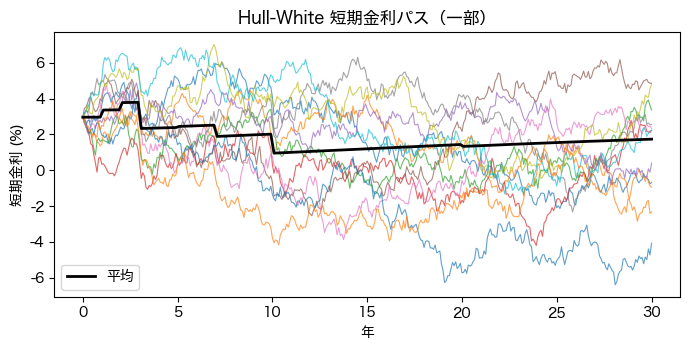

In [5]:
N_PATHS = 3000
times, rates = simulate_hull_white(HW_A, HW_SIGMA, curve, WAM, N_PATHS, SEED)
disc, tm, pm = path_discount_factors(rates, curve, WAM)

# 再基準化により、パス割引の平均が市場カーブに一致することを確認。
df_bp = (disc.mean(axis=0) - pm) * 1e4
print(f"再基準化後の平均割引と市場DFの最大差: {np.max(np.abs(df_bp)):.2e} bp（DF単位）")

fig, ax = plt.subplots(figsize=(7, 3.6))
for j in range(12):
    ax.plot(times, rates[j] * 100, lw=0.8, alpha=0.7)
ax.plot(times, rates.mean(axis=0) * 100, "k", lw=2, label="平均")
ax.set_xlabel("年"); ax.set_ylabel("短期金利 (%)"); ax.set_title("Hull-White 短期金利パス（一部）")
ax.legend(); fig.tight_layout()

## QuantLib 検証

**この検証の位置づけを明記します。** QuantLib には、期限前償還を内生化した
パス依存 MBS の OAS を直接計算する既製エンジンがありません。そこで本notebookの
妥当性検証は、**プリペイメントをゼロにすると MC-OAS が通常の Zスプレッドに一致する**
ことをもって行います。プリペイメントが無ければ CF はパスに依らず一意（＝予定元本の
みの確定 CF）になるため、

$$
\frac{1}{N}\sum_j \sum_m CF_m\, \text{disc}^{(j)}_m e^{-s t_m}
= \sum_m CF_m\, \Big(\tfrac{1}{N}\sum_j \text{disc}^{(j)}_m\Big) e^{-s t_m}
= \sum_m CF_m\, DF^M(t_m)\, e^{-s t_m}
$$

となり（最後の等号は割引の再基準化により平均割引が市場DFに一致するため）、
MC-OAS の求解式は Zスプレッドの求解式に一致します。よって両者は数値的にも一致する
はずです。**独立系の答え合わせ**として、確定 CF の Zスプレッドを QuantLib の
`CashFlows.zSpread` でも計算し、自作値と突合します。

In [6]:
# プリペイメントをゼロにした確定キャッシュフロー。
smm_zero_paths = np.zeros((N_PATHS, WAM))
cf_zero_paths, _ = pool_cashflows(BALANCE, WAC, WAM, smm_zero_paths)
cf_zero = pool_cashflows(BALANCE, WAC, WAM, np.zeros((1, WAM)))[0][0]   # 確定CF（1本）

# 検証用の任意の市場価格を、確定CFに 40bp を乗せた価格として設定。
price_check = float(np.sum(cf_zero * pm * np.exp(-0.004 * tm)))

oas_zero = solve_oas(cf_zero_paths, disc, tm, price_check)
z_zero = solve_zspread(cf_zero, pm, tm, price_check)
print(f"プリペイメント・ゼロ:  MC-OAS = {oas_zero*1e4:.4f} bp,  Zスプレッド = {z_zero*1e4:.4f} bp")
print(f"差: {abs(oas_zero - z_zero)*1e6:.4f} × 10^-6（bp未満）")
assert abs(oas_zero - z_zero) < 1e-6

プリペイメント・ゼロ:  MC-OAS = 40.0000 bp,  Zスプレッド = 40.0000 bp
差: 0.0000 × 10^-6（bp未満）


In [7]:
import QuantLib as ql

today = ql.Date(15, 5, 2026)
ql.Settings.instance().evaluationDate = today
day_count = ql.Actual365Fixed()

q_dates = [today] + [today + ql.Period(m, ql.Months) for m in range(1, WAM + 1)]
q_dfs = [1.0] + [float(curve.discount(m / 12.0)) for m in range(1, WAM + 1)]
q_curve = ql.DiscountCurve(q_dates, q_dfs, day_count)

leg = [ql.SimpleCashFlow(float(cf_zero[m - 1]), today + ql.Period(m, ql.Months))
       for m in range(1, WAM + 1)]
z_ql = ql.CashFlows.zSpread(leg, price_check, q_curve, day_count,
                            ql.Continuous, ql.Annual, True)
print(f"QuantLib Zスプレッド = {z_ql*1e4:.4f} bp,  自作 Zスプレッド = {z_zero*1e4:.4f} bp")
print(f"差: {(z_ql - z_zero)*1e4:.4f} bp（日数計算規約の違いによる微差）")
assert abs(z_ql - z_zero) < 5e-4     # 5bp 以内

QuantLib Zスプレッド = 39.9655 bp,  自作 Zスプレッド = 40.0000 bp
差: -0.0345 bp（日数計算規約の違いによる微差）


三者（MC-OAS・自作 Zスプレッド・QuantLib Zスプレッド）が一致しました。プリペイメントを
消すと MC-OAS エンジンが通常の Zスプレッド計算へ退化することが確認でき、エンジンの
割引・求解部分が正しいことの裏づけになります。次節ではプリペイメントを入れて、両者が
乖離する（＝オプションコストが生じる）様子を見ます。

## 実データ適用

合成カーブ＋Hull-White＋ロジスティック期限前償還モデルで、MBS の OAS・Zスプレッド・
オプションコストを分解します。まず基準ケースの CF を作り、市場価格を「OAS=50bp 相当」で
定義してから、各スプレッドを求解します。

In [8]:
def build_prepay_smm(hw, times, rates, wac):
    """金利パス → 借換金利 → インセンティブ → CPR → SMM を組み立てる（パス別）。"""
    refi = hw_refi_rate(hw, times, rates)          # (n_paths, wam+1)
    age = np.arange(1, WAM + 1)                     # 月末の経過月
    incentive = wac - refi[:, 1:]                   # 各月末のインセンティブ
    cpr = prepay_cpr(age[None, :], incentive)
    return cpr_to_smm(cpr), refi, incentive


def base_case_smm(curve, wac):
    """Zスプレッド用の単一シナリオ SMM（フォワード金利に沿った決定論的な期限前償還）。"""
    tm_local = np.arange(1, WAM + 1) * DT
    refi_det = np.array([-np.log(curve.discount(t + REFI_TENOR) / curve.discount(t)) / REFI_TENOR
                         for t in tm_local])
    age = np.arange(1, WAM + 1)
    cpr = prepay_cpr(age, wac - refi_det)
    return cpr_to_smm(cpr)[None, :]


def run_mc_oas(a, sigma, curve, wac, n_paths, seed, price):
    """指定ボラで MC-OAS・Zスプレッド・オプションコストを求める。"""
    hw_local = HullWhite(a, sigma, curve)
    t_loc, r_loc = simulate_hull_white(a, sigma, curve, WAM, n_paths, seed)
    disc_loc, tm_loc, pm_loc = path_discount_factors(r_loc, curve, WAM)
    smm_paths, _, _ = build_prepay_smm(hw_local, t_loc, r_loc, wac)
    cf_paths, prin_paths = pool_cashflows(BALANCE, wac, WAM, smm_paths)
    oas = solve_oas(cf_paths, disc_loc, tm_loc, price)
    # Zスプレッドはボラ非依存（フォワード・シナリオの確定CF）。
    smm_base = base_case_smm(curve, wac)
    cf_base = pool_cashflows(BALANCE, wac, WAM, smm_base)[0][0]
    z = solve_zspread(cf_base, pm_loc, tm_loc, price)
    wal = float(np.mean([weighted_average_life(
        {"month": np.arange(1, WAM + 1), "total_principal": prin_paths[j]})
        for j in range(0, n_paths, max(1, n_paths // 200))]))
    return dict(oas=oas, zspread=z, option_cost=z - oas, wal=wal)

In [9]:
# 基準ケースの CF から市場価格を定義（真の OAS を 50bp に設定して逆算）。
smm_base_paths, refi_paths, incentive_paths = build_prepay_smm(hw, times, rates, WAC)
cf_base_paths, prin_base_paths = pool_cashflows(BALANCE, WAC, WAM, smm_base_paths)
OAS_TRUE = 0.0050
price_market = price_given_oas(cf_base_paths, disc, tm, OAS_TRUE)
print(f"想定市場価格（額面100あたり）: {price_market:.4f}")

res_base = run_mc_oas(HW_A, HW_SIGMA, curve, WAC, N_PATHS, SEED, price_market)
print(f"MC-OAS       : {res_base['oas']*1e4:6.1f} bp")
print(f"Zスプレッド   : {res_base['zspread']*1e4:6.1f} bp")
print(f"オプションコスト: {res_base['option_cost']*1e4:6.1f} bp")
print(f"平均 WAL     : {res_base['wal']:.2f} 年")

想定市場価格（額面100あたり）: 105.3947


MC-OAS       :   50.0 bp
Zスプレッド   :   56.0 bp
オプションコスト:    6.0 bp
平均 WAL     : 3.95 年


### 借換インセンティブと CPR の断面

「どの金利をインセンティブに使うか」を可視化します。基準（フォワード）シナリオの
借換金利と、それが生む CPR プロファイルを示します。金利が下がってインセンティブが
正に振れる局面で CPR が跳ね上がる、S字の効きが読み取れます。

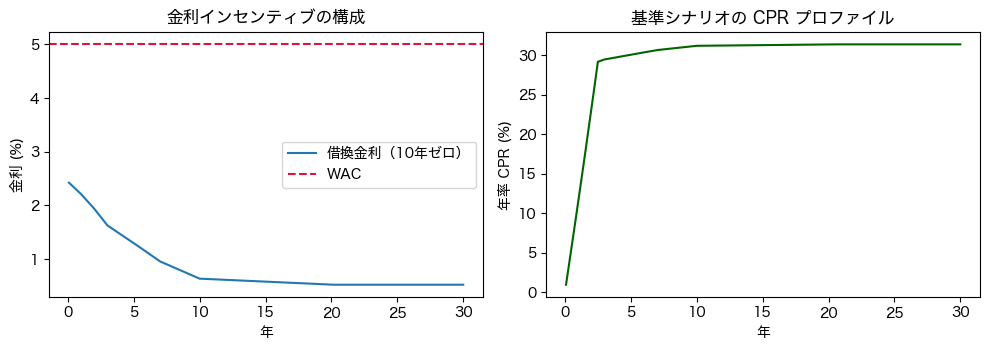

In [10]:
tm_years = tm
refi_det = np.array([-np.log(curve.discount(t + REFI_TENOR) / curve.discount(t)) / REFI_TENOR
                     for t in tm_years])
incentive_det = WAC - refi_det
cpr_det = prepay_cpr(np.arange(1, WAM + 1), incentive_det)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(tm_years, refi_det * 100, label="借換金利（10年ゼロ）")
axes[0].axhline(WAC * 100, color="crimson", ls="--", label="WAC")
axes[0].set_xlabel("年"); axes[0].set_ylabel("金利 (%)")
axes[0].set_title("金利インセンティブの構成"); axes[0].legend()
axes[1].plot(tm_years, cpr_det * 100, color="darkgreen")
axes[1].set_xlabel("年"); axes[1].set_ylabel("年率 CPR (%)")
axes[1].set_title("基準シナリオの CPR プロファイル")
fig.tight_layout()

### 金利ボラを2倍にしたときの変化

短期金利ボラ $\sigma$ を基準（1.0%）から2倍（2.0%）へ引き上げ、分解の変化を見ます。
市場価格は据え置きます。

In [11]:
res_hi = run_mc_oas(HW_A, 2 * HW_SIGMA, curve, WAC, N_PATHS, SEED, price_market)

table = pd.DataFrame({
    "σ = 1.0%（基準）": [res_base["oas"] * 1e4, res_base["zspread"] * 1e4,
                         res_base["option_cost"] * 1e4],
    "σ = 2.0%（2倍）": [res_hi["oas"] * 1e4, res_hi["zspread"] * 1e4,
                        res_hi["option_cost"] * 1e4],
}, index=["OAS (bp)", "Zスプレッド (bp)", "オプションコスト (bp)"])
display(table.round(1))

,σ = 1.0%（基準）,σ = 2.0%（2倍）
OAS (bp),50.0,29.2
Zスプレッド (bp),56.0,56.0
オプションコスト (bp),6.0,26.9


**読み取り。** Zスプレッドはボラに依らずほぼ一定です（確定シナリオの CF を市場カーブで
割引くだけなので、金利ボラの情報が入りません）。一方でボラを2倍にすると、繰上返済
オプションの価値が増すためオプションコストが拡大し、同じ市場価格に合わせるには OAS が
低下します。オプションコスト＝Zスプレッド−OAS の分解が、ボラ上昇のインパクトを OAS 側に
押し付けている構図です。MBS の割安・割高を語るには、見かけの Zスプレッドではなく
オプション調整後の OAS で比較すべき、という実務上の結論につながります。

## 演習

1. **金利ボラとオプションコスト。** 短期金利ボラ $\sigma$ を 0.4%〜2.4% の範囲で
   振り、各 $\sigma$ で OAS・Zスプレッド・オプションコストを求めて、$\sigma$ に対する
   オプションコストの曲線を描け。市場価格は本文と同じに固定してよい。オプションコストが
   $\sigma$ に対して単調に増えることと、Zスプレッドがほぼ一定であることを確認し、その
   理由を一言で述べよ。
2. **パス数と OAS の標準誤差。** パス数 $N$ を 500, 1000, 2000, 4000 と変え、各 $N$ で
   シード違いの OAS を複数回推定して標準偏差（＝OAS 推定の標準誤差）を求めよ。標準誤差が
   概ね $1/\sqrt{N}$ で縮むことを、両対数プロットで確認せよ。精度を2bp→1bp に半減させる
   には、パス数を何倍にする必要があるかを述べよ。

解答例は `solutions/S8/sol_0802.py` に置きます。

## 用語集

定義の正は `glossary/08_securitization.md`。ここでは初出語の一行要約のみ示します。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| [MC-OAS](../../glossary/08_securitization.md#monte-carlo-oas) | Monte Carlo OAS | 金利パスをMC生成し、平均価格が市場価格に一致するスプレッドとしてOASを求解する評価法 |
| [OAS](../../glossary/08_securitization.md#option-adjusted-spread) | option-adjusted spread | 内包オプションをCF側で織り込んだ後に残る、パス割引への一律上乗せスプレッド |
| [Zスプレッド](../../glossary/08_securitization.md#z-spread-zero-volatility-spread) | Z-spread | ボラゼロの単一シナリオCFをカーブへ一律上乗せで割引いて価格一致させるスプレッド |
| [パス依存](../../glossary/08_securitization.md#path-dependent) | path-dependent | CFが金利のたどった経路全体に依存する性質。MC評価が要る理由 |
| [オプションコスト](../../glossary/08_securitization.md#option-cost) | option cost | Zスプレッド−OAS。借り手の繰上返済オプション価値のスプレッド換算 |
| [金利インセンティブ](../../glossary/08_securitization.md#refinancing-incentive) | refinancing incentive | WAC−借換金利。金利パスをプリペイメントモデルへ結合する接点 |